# Single Particle Tracking simulator

In [1]:
import helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *

In [2]:
%reload_ext autoreload
%autoreload 2

## 1. Particles simulator

Generate frames with moving particles following normal diffusion (Brownian motion)

In [3]:
F = 20
N = 15
frames, trajectories_GT, D_GT = generate_frames_random(F, N, D=None, amp = 2000, noise_gaussian=True, noise_poisson=True)

Frame 0
Frame 10
Trajectory 0 cropped at start by 5 frames
Trajectory 4 cropped at start by 1 frames
Trajectory 5 cropped at start by 1 frames
Trajectory 6 cropped at start by 6 frames
Trajectory 7 cropped at end by 3 frames
Trajectory 8 cropped at end by 2 frames
Trajectory 10 cropped at start by 2 frames
Trajectory 11 cropped at start by 5 frames
Trajectory 11 cropped at end by 5 frames
Trajectory 12 cropped at start by 1 frames
Trajectory 13 cropped at end by 6 frames
Trajectory 14 cropped at start by 5 frames


In [4]:
viewer = view_frames(frames)
viewer

In [5]:
check_min_max(frames[0])

min: 0.0
max: 2048.345067496772


-> can see gaussian noise very well when zooming in saved picture.  

## 2. Diffusion coefficients estimation

### 2.0 $ D_{GT} $

In [6]:
print('D_GT =', D_GT)

D_GT = [4, 2, 4, 1, 1, 3, 3, 1, 2, 1, 3, 2, 4, 2, 1]


### 2.1 $ D_{trajectory} $

In [7]:
calculate_msd_trajectories(trajectories_GT)

In [8]:
D_trajectory = estimateDfromTrajectories_safer(trajectories_GT)
print(f"D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in D_trajectory)}]")

D_trajectory: 
[4.387, 0.710, 0.738, 0.430, 0.456, 0.464, 4.024, 0.120, 1.130, 0.224, 2.834, 0.351, 0.555, 0.826, 0.413]


In [9]:
MAE_trajectory = np.abs(np.array(D_trajectory) - np.array(D_GT))
print(f"MAE for D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in MAE_trajectory)}]")

MAE for D_trajectory: 
[0.387, 1.290, 3.262, 0.570, 0.544, 2.536, 1.024, 0.880, 0.870, 0.776, 0.166, 1.649, 3.445, 1.174, 0.587]


*=> D of 0 is perfectly estimated*

### 2.2 $ D_{detection} $

Detection followed by Local Nearest Neighbor tracking

In [10]:
detected_peaks = detect_peaks(frames)

In [11]:
trajectories_detection = NN_tracking_enhanced(detected_peaks, max_distance=5)

print("Number of trajectories:", len(trajectories_detection))
print("Sizes of trajectories:", [len(traj.get_positions()) for traj in trajectories_detection])

Number of trajectories: 16
Sizes of trajectories: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 2, 20, 18, 11]


### Assignment of detected trajectories to GT trajectories

In [12]:
# assignment using the Hungarian algorithm
trajectories_detection, min_cost, assignment_detection = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian', verbose=True)

Cost matrix:
[[6.56618927e+01 3.32927878e+01 4.02272458e+00 7.09397882e+01
  1.06940625e+02 5.25030754e+01 8.47462978e+01 4.55246723e+01
  5.87461044e+01 6.45432959e+01 9.56494347e+01 1.68257386e+01
  7.10968378e+01 9.05805172e+01 8.74584931e+01]
 [1.27555065e+02 7.47172823e+01 1.07096945e+02 3.62246479e+01
  1.14947240e+00 1.31856319e+02 1.52314508e+02 7.81166382e+01
  6.81870757e+01 9.54393553e+01 1.26933359e+01 1.13309265e+02
  6.75404202e+01 2.14754998e+01 9.56004579e+01]
 [1.20315157e+02 6.04286313e+01 9.09451249e+01 2.17156996e+01
  2.19578077e+01 1.22077181e+02 1.45299028e+02 7.01967051e+01
  6.34385176e+01 9.18054256e+01 1.45637368e+01 9.47352087e+01
  6.63474570e+01 2.26982295e+00 9.68937107e+01]
 [4.93816790e+01 7.03160602e+01 8.80368065e+01 8.13469262e+01
  9.63894913e+01 6.61006663e+01 6.75761866e+01 4.73325151e+01
  4.08007194e+01 2.42677577e+01 9.02923028e+01 1.04579434e+02
  3.22559234e+01 9.90817954e+01 1.05127209e+00]
 [5.20161870e+01 2.34790968e+01 4.49657489e+01 4.88

In [13]:
# pypi algo not functional on rectangular cost matrix
#trajectories_detection_pypi, assignment_pypi = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian_pypi')

In [14]:
# compare_assignments(assignment, assignment_pypi)

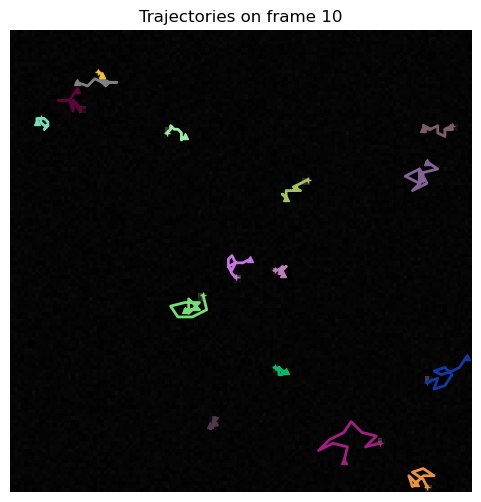

In [15]:
show_trajectories(frames, trajectories_detection, frame_id=10)

In [16]:
calculate_msd_trajectories(trajectories_detection)

In [17]:
D_detection = estimateDfromTrajectories_safer(trajectories_detection)
print(f"D_detection: \n[{', '.join(f'{float(d):.3f}' for d in D_detection)}]")

D_detection: 
[0.881, 0.296, 1.139, 0.227, 0.165, 0.498, 0.607, 0.256, 6.583, 0.465, 0.588, 0.846, 0.500, 1.307, 2.907, 0.569]


In [18]:
# calculate MAE for D_detection
MAE_detection = compute_MAE_detection(trajectories_detection, D_GT)

D_detection:
['6.583', '0.846', '0.881', '0.498', '0.296', '0.588', '0.569', '0.165', '1.307', '0.256', '2.907', '0.607', '0.465', '0.500', '0.227']
MAE for D_detection:
['2.583', '1.154', '3.119', '0.502', '0.704', '2.412', '2.431', '0.835', '0.693', '0.744', '0.093', '1.393', '3.535', '1.500', '0.773']


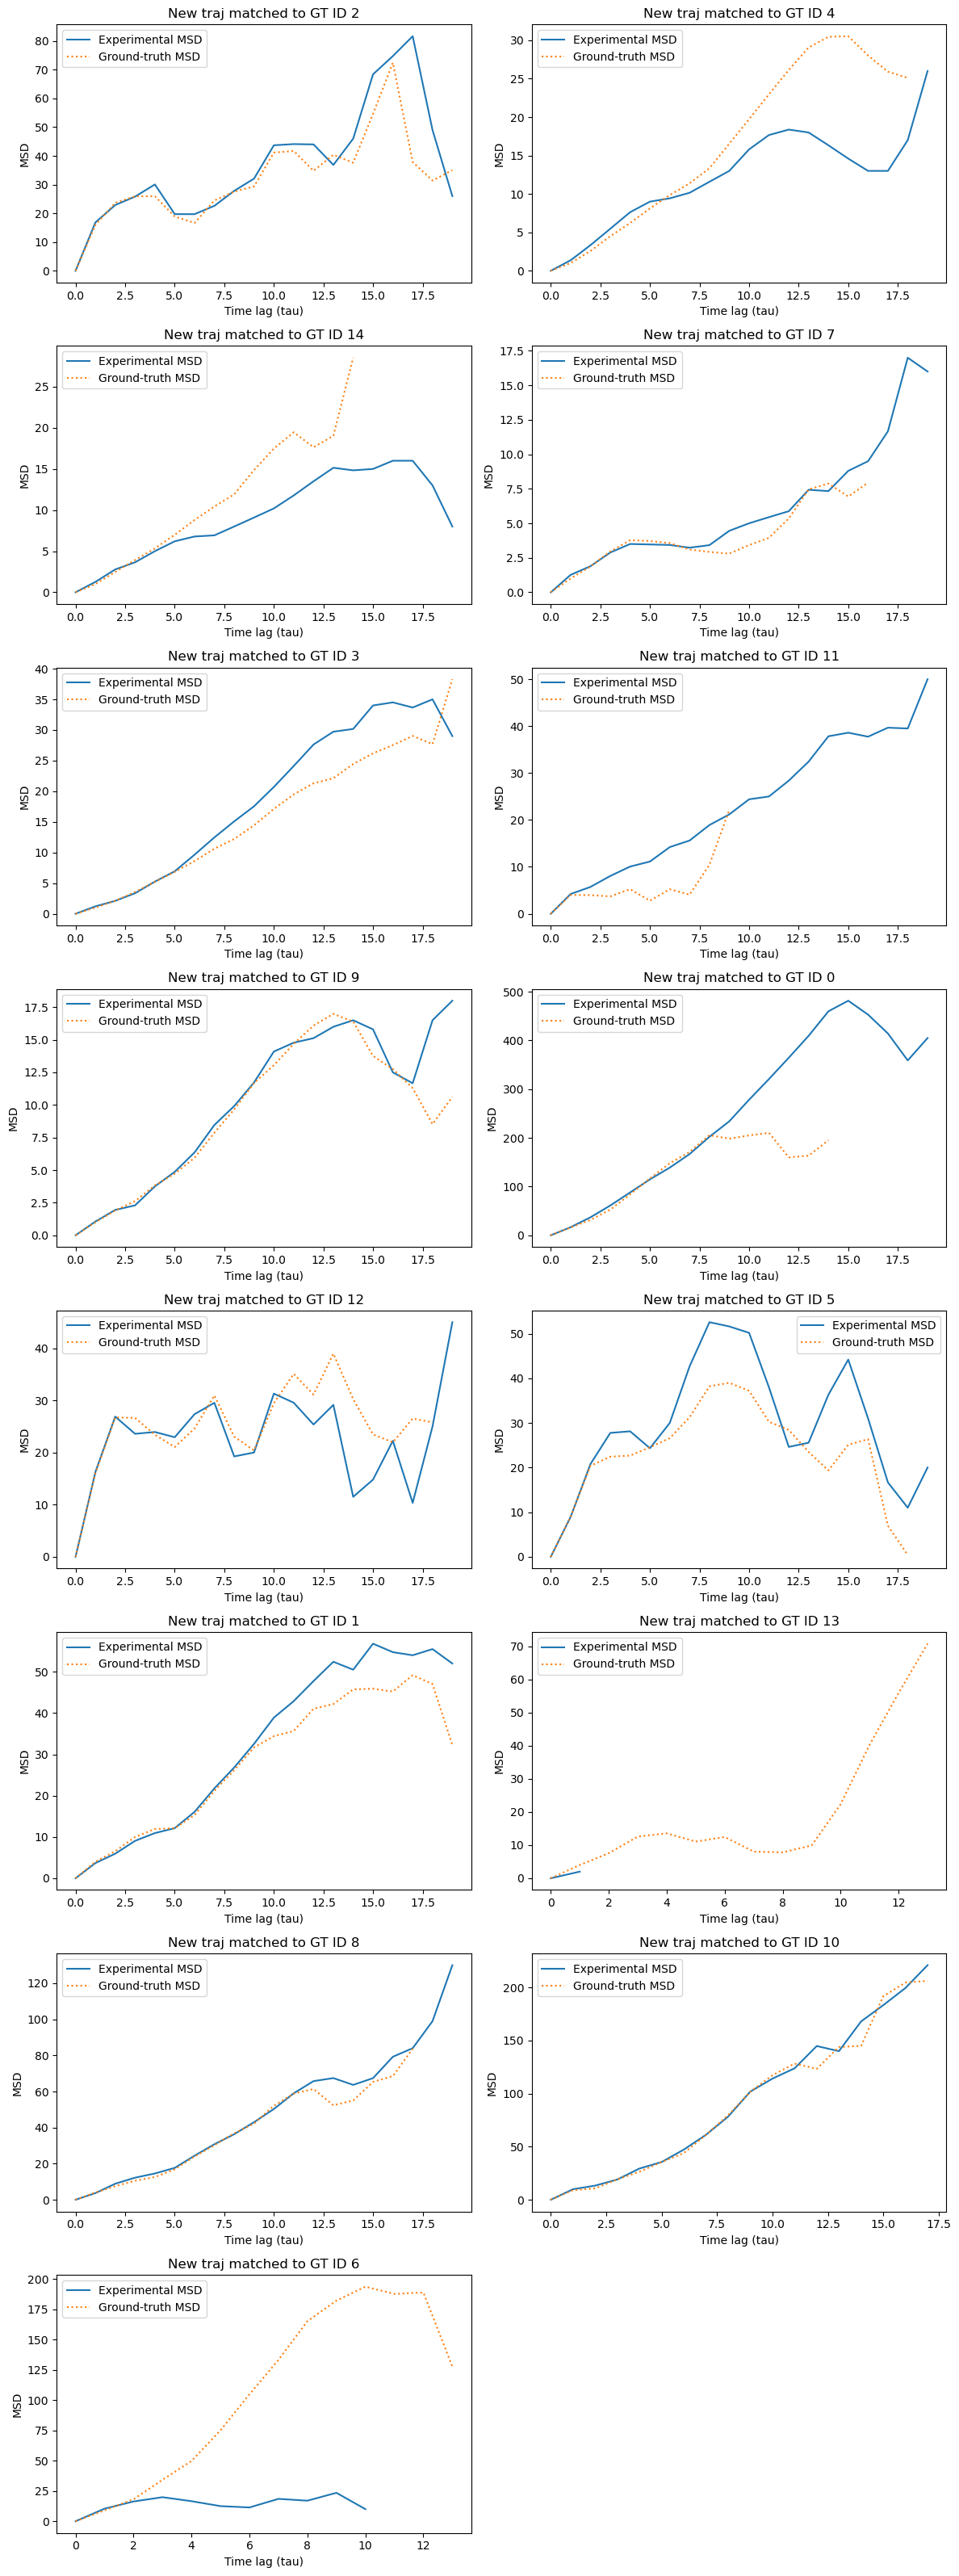

In [19]:
plot_msd_vs_trajectory_msd(trajectories_detection, trajectories_GT)

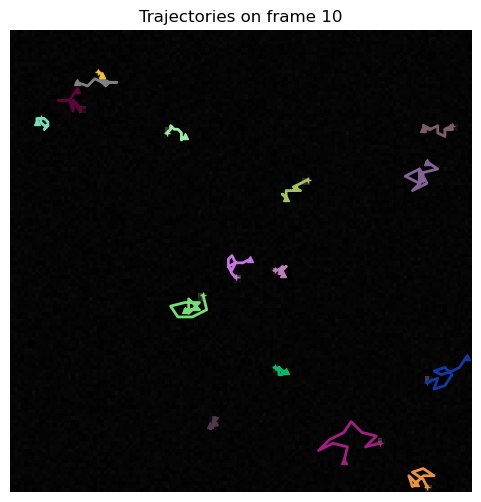

In [33]:
show_trajectories(frames, trajectories_detection, frame_id=10)

### 3.3 $ D_{localization} $

By Gaussian fitting

Fitted center for peak at (36, 115): (35.94, 114.92), amplitude 1977.67, sigma 0.50


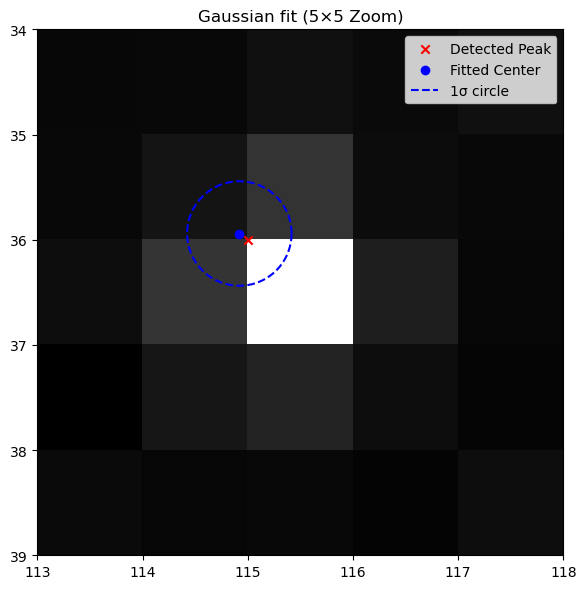

Fitted center for peak at (25, 7): (24.84, 6.98), amplitude 1969.10, sigma 0.51
Fitted center for peak at (14, 18): (14.23, 17.95), amplitude 1933.24, sigma 0.52
Fitted center for peak at (109, 55): (109.31, 55.03), amplitude 2029.79, sigma 0.50
Fitted center for peak at (67, 75): (67.12, 75.30), amplitude 2009.23, sigma 0.48
Fitted center for peak at (29, 48): (29.34, 47.89), amplitude 2003.88, sigma 0.51
Fitted center for peak at (27, 114): (27.34, 113.84), amplitude 2034.39, sigma 0.50
Fitted center for peak at (94, 76): (94.03, 75.60), amplitude 1997.58, sigma 0.49
Fitted center for peak at (119, 92): (118.94, 91.58), amplitude 1949.88, sigma 0.51
Fitted center for peak at (77, 48): (77.32, 47.65), amplitude 2231.36, sigma 0.47
Fitted center for peak at (46, 76): (45.96, 76.45), amplitude 1973.87, sigma 0.50
Fitted center for peak at (124, 110): (124.30, 109.51), amplitude 1773.30, sigma 0.56
Fitted center for peak at (12, 25): (11.60, 25.41), amplitude 1716.86, sigma 0.55
Fitted c

In [21]:
# 1min50 rutime for 100 frames
localized_peaks = localize_peaks_with_gaussian_fitting(frames, detected_peaks, verbose=True, visualization=True)

In [22]:
# should be able to pick up trajs that start after first frame!
trajectories_localization = NN_tracking_enhanced(localized_peaks, max_distance=5)

In [23]:
print("Number of localized trajectories:", len(trajectories_localization))

Number of localized trajectories: 16


In [24]:
# assignment using the Hungarian algorithm
trajectories_localization, min_cost,assignment_localization = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='hungarian', verbose=True)

Cost matrix:
[[6.56817817e+01 3.32405959e+01 3.99034356e+00 7.08937752e+01
  1.06896811e+02 5.25315933e+01 8.47994178e+01 4.55020941e+01
  5.87188837e+01 6.45376743e+01 9.55883555e+01 1.68837436e+01
  7.10748562e+01 9.05343027e+01 8.74206033e+01]
 [1.27610001e+02 7.47134438e+01 1.07094116e+02 3.62243188e+01
  9.96198854e-01 1.31843654e+02 1.52374542e+02 7.81218762e+01
  6.81975728e+01 9.54304372e+01 1.27366754e+01 1.13399039e+02
  6.75176387e+01 2.14916934e+01 9.56467203e+01]
 [1.18220330e+02 6.47753774e+01 9.65115583e+01 2.60231761e+01
  1.29946685e+01 1.23042024e+02 1.42377975e+02 7.11247072e+01
  6.19393553e+01 8.89483052e+01 2.99601031e+00 1.02717532e+02
  6.15155706e+01 1.07022518e+01 8.91971961e+01]
 [4.94909263e+01 7.03516860e+01 8.80889180e+01 8.13452375e+01
  9.63472875e+01 6.61716015e+01 6.77155843e+01 4.73525466e+01
  4.08171959e+01 2.43267044e+01 9.02533723e+01 1.04618979e+02
  3.22491786e+01 9.90742702e+01 9.90570733e-01]
 [5.20587495e+01 2.34574889e+01 4.49260448e+01 4.88

In [25]:
calculate_msd_trajectories(trajectories_localization)

In [26]:
print(len(trajectories_localization))

16


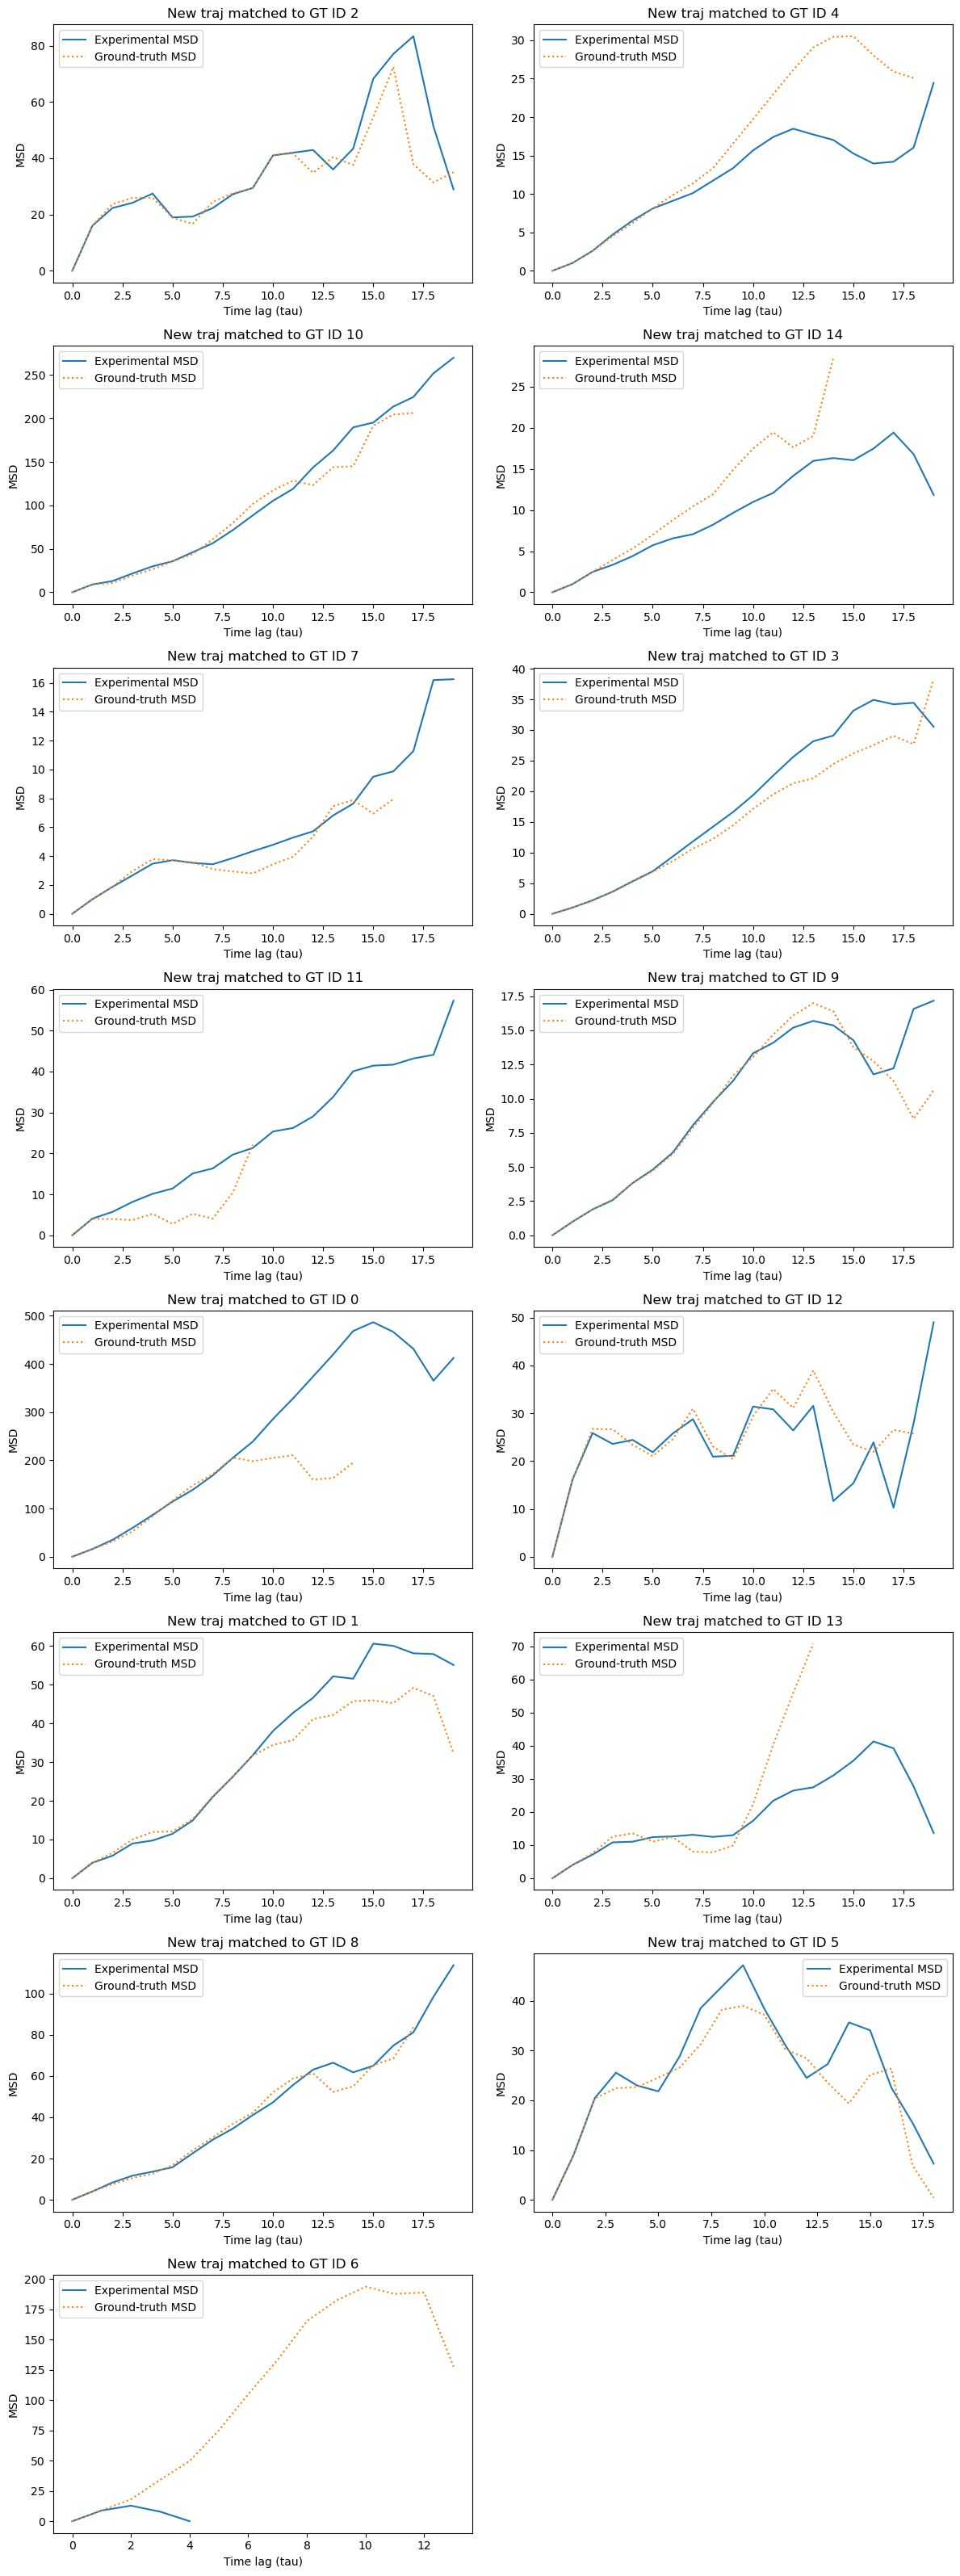

In [27]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)

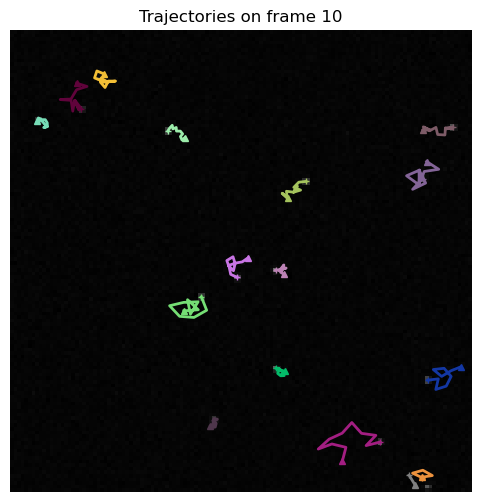

In [28]:
show_trajectories(frames, trajectories_localization, frame_id=10)

In [29]:
D_localization = estimateDfromTrajectories(trajectories_localization)
print(f"D_localization: \n[{', '.join(f'{float(d):.3f}' for d in D_localization)}]")

D_localization: 
[0.881, 0.295, 3.151, 0.256, 0.164, 0.489, 0.657, 0.248, 6.727, 0.488, 0.873, 0.476, 1.238, 0.555, 2.246, 0.487]


In [30]:
# calculate MAE for D_localization
MAE = {}
for traj in trajectories_localization:
    MAE[traj.id] = compute_MAE(traj.D_localization, traj.D_trajectory)
print("MAE for D_localization:")
for traj_id, mae in MAE.items():
    if traj_id is not None and traj_id is not -1:
        print(f"{traj_id}: {mae:.3f}")

MAE for D_localization:
2: 0.881
4: 0.295
10: 3.151
14: 0.256
7: 0.164
3: 0.489
11: 0.657
9: 0.248
0: 6.727
12: 0.488
1: 0.873
13: 0.476
8: 1.238
5: 0.555
-1: 2.246
6: 0.487


<>:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\armel\AppData\Local\Temp\ipykernel_5740\474422645.py:7: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if traj_id is not None and traj_id is not -1:


### Linear trajectories visualization

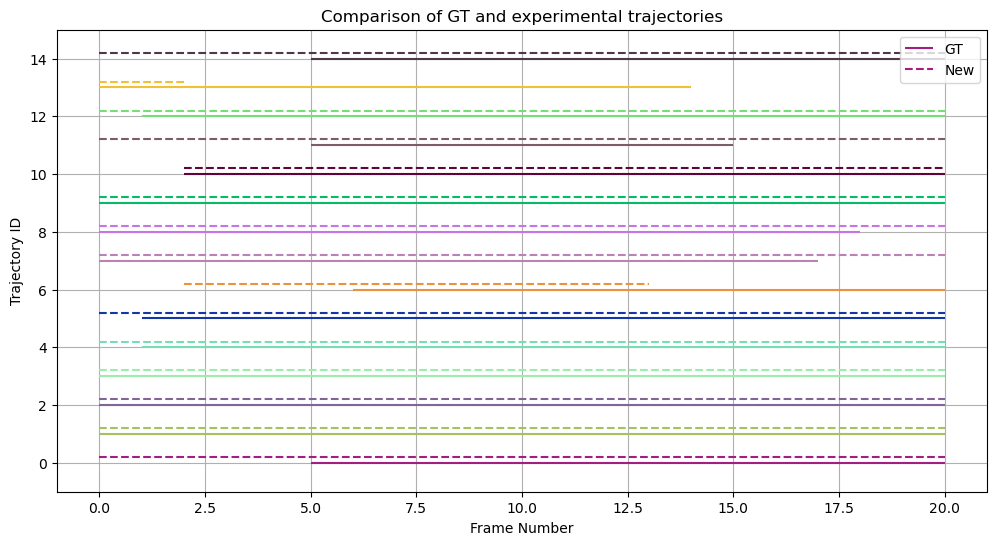

In [31]:
linear_trajectories_visualizer(trajectories_detection, trajectories_GT)

-> start cropping not functional: just crops and moves remaining positions towards 0

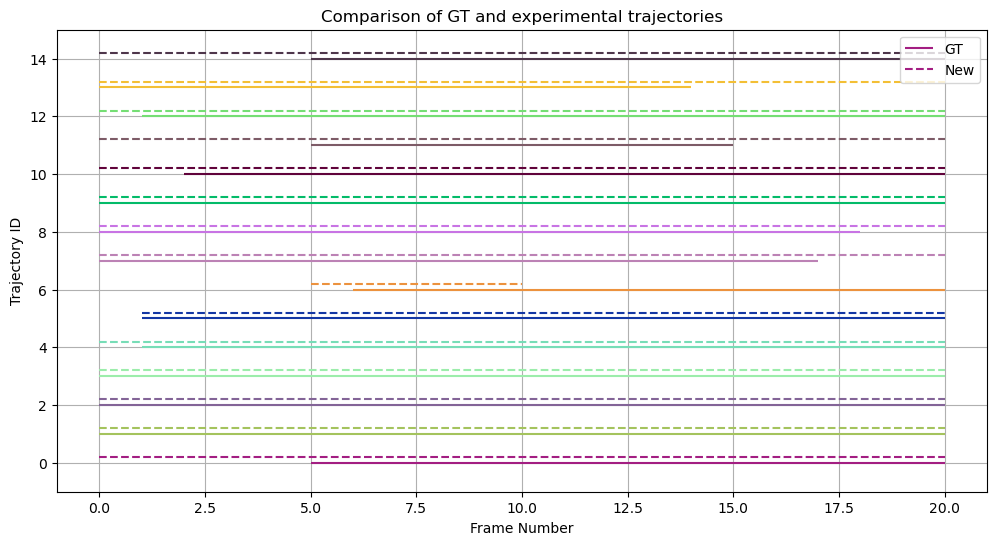

In [32]:
linear_trajectories_visualizer(trajectories_localization, trajectories_GT)